In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
import os
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, conditional, pi
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
import cmcrameri.cm as cmc
from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)

In [2]:
os.getcwd()

'/home/icepack/sync/blue_glacier/code/liam_notebooks'

# Load in Blue Glacier Files:

In [3]:
# Direct from Farinotti data
m1_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_1.tif'
m2_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_2.tif'
m3_h  = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_model_3.tif'
far_h = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_farinotti_composite.tif'
blue_surf = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_surface_DEM.tif'

# Rasters constructed using Farinotti data & DEM
blue_bed_comp =  '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_bedrock_far_composite.tif'
blue_bed_m1   =  '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_bedrock_DEM_far_model1.tif'
blue_bed_m2   =  '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_bedrock_DEM_far_model2.tif'
blue_bed_m3   =  '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_bedrock_DEM_far_model3.tif'

# Constructed outline
outline_filename = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue.geojson'

# ITS_LIVE velocity 
il_velo = '/home/icepack/sync/blue_glacier/data/qgis_blue/blue_ITS_LIVE_velocity_120m_composite.tif'

# Make mesh

In [4]:
with open(outline_filename, "r") as outline_file:
    outline = geojson.load(outline_file)

In [5]:
gmsh_mesh = icepack.meshing.collection_to_gmsh(outline)
gmsh_mesh.write("blue.msh", verbose=False)

mesh = firedrake.Mesh("blue.msh") # Initial mesh

In [6]:
from firedrake.mg.mesh import MeshHierarchy

mesh0 = firedrake.Mesh('blue.msh')
hierarchy = MeshHierarchy(mesh0, 3, 1) # I'm unsure if a mesh hierarchy is needed if we're going to do adaptive

mesh = hierarchy[0] 

In [7]:
# This cell is gold for things later
cell_sizes = mesh.cell_sizes.dat.data_ro

print(f'Cells: {mesh.num_cells()}')
print(f'Min: {cell_sizes.min()} m')
print(f'Max: {cell_sizes.max()} m')
print(f'Avg: {cell_sizes.mean()} m')

Cells: 567
Min: 32.21204029831187 m
Max: 457.02138063393437 m
Avg: 183.79866155009674 m


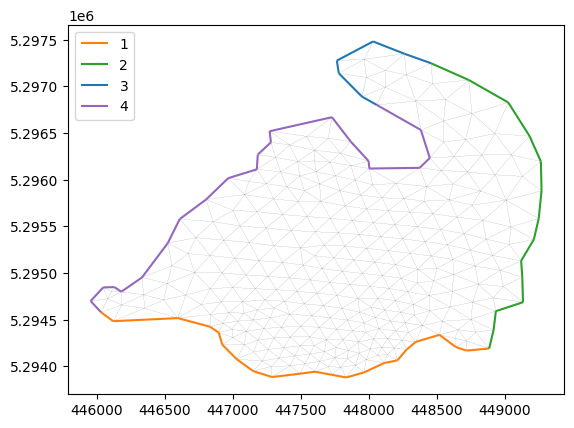

In [8]:
fig, axes = plt.subplots()
kw = {
    "boundary_kw": {"colors": ["tab:orange", "tab:green", "tab:blue", "tab:purple"]},
    "interior_kw": {"linewidth": 0.03}, # Change lw val to smaller number to make boundaries easier to see
}
firedrake.triplot(mesh, axes=axes, **kw)
axes.legend(loc="upper left");

In [9]:
## Function Spaces
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
cg1 = firedrake.FiniteElement("CG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1) 
V = firedrake.VectorFunctionSpace(mesh, cg1)

# Plot each to see if they all line up

## Surface DEM, Farinotti Composite, and Far. Comp. Bed DEMs

In [10]:
coords = np.array(list(geojson.utils.coords(outline)))
delta = 1e3
extent = {
    "left": coords[:, 0].min(),
    "right": coords[:, 0].max(),
    "bottom": coords[:, 1].min(),
    "top": coords[:, 1].max(),
}

In [11]:
print(extent)

{'left': np.float64(445956.749067), 'right': np.float64(449270.324317), 'bottom': np.float64(5293879.649671), 'top': np.float64(5297480.198685)}


In [12]:
# Farinotti Composite Thickness
surf_file_far = rasterio.open(far_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file_far.transform).round_lengths().round_offsets()
transform = surf_file_far.window_transform(window)
CompositeSurf_obs = surf_file_far.read(window=window)

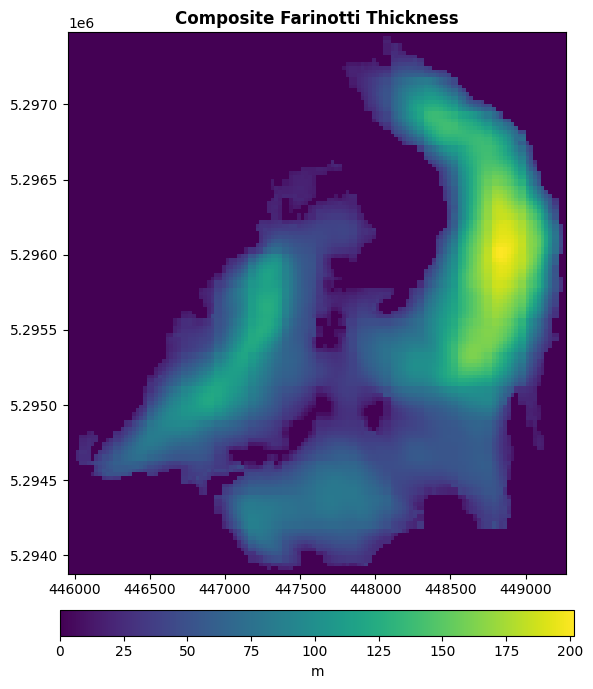

In [13]:
fig, ax = plt.subplots(1, 1, figsize = [6, 7], sharey = True)

colors = ax.imshow(CompositeSurf_obs[0, :, :],
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap2,
                      #vmin = 1500,
                      axes=ax)
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.05, pad=0.06)
ax.set_title('Composite Farinotti Thickness', fontweight = 'bold')
ax.set_aspect("equal")

plt.tight_layout()

In [14]:
# Surface DEM
surf_file = rasterio.open(blue_surf)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=surf_file.transform).round_lengths().round_offsets()
transform = surf_file.window_transform(window)
s_obs = surf_file.read(window=window)

# Filtering Fill Vals
s_obs = s_obs[0, :, :]
s_obs[s_obs < 0] = 0

# Farinotti Composite Bed File
bed_file = rasterio.open(blue_bed_comp)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs_comp = bed_file.read(window=window)

# Filtering Fill Vals
b_obs_comp = b_obs_comp[0, :, :]
b_obs_comp[b_obs_comp < 0] = 0

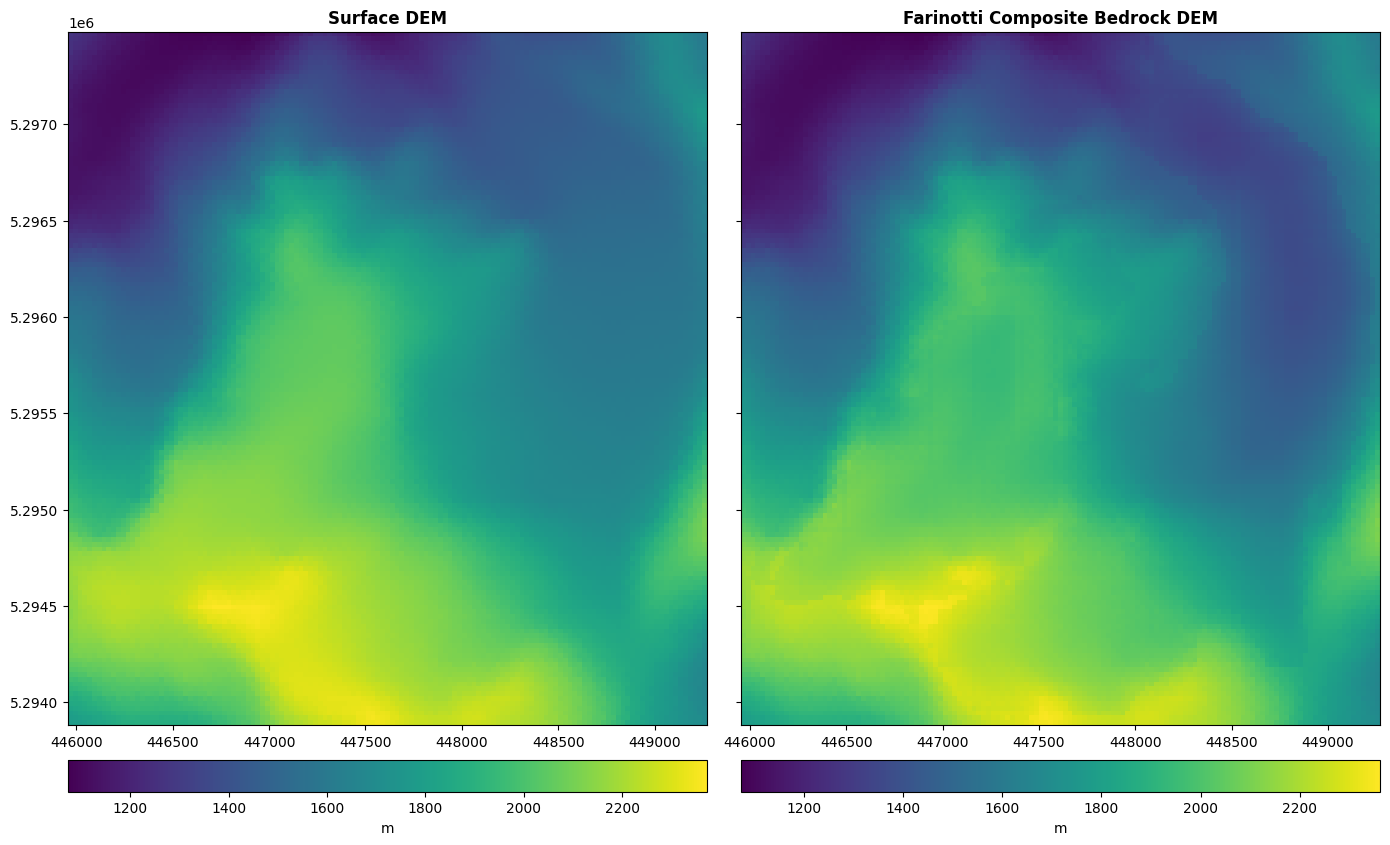

In [15]:
# Surface and Bed File: Farinotti Composite
cmap3 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'tab:orange'])
fig, ax = plt.subplots(1, 2, figsize = [14, 12], sharey = True)

colors = ax[0].imshow(s_obs, 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap3,
                      #vmin = 1500,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[0].set_title('Surface DEM', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(b_obs_comp, 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      #cmap = cmap3,
                      #vmin = 1500,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'bottom', fraction=0.046, pad=0.03)
ax[1].set_title('Farinotti Composite Bedrock DEM', fontweight = 'bold')
ax[1].set_aspect("equal")

plt.tight_layout()

## Far. Models 1,2,3 and Far. Models 1,2,3 Bedrock DEMs

In [16]:
# Farinotti Thickness Model 1
m1_file = rasterio.open(m1_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m1_file.transform).round_lengths().round_offsets()
transform = m1_file.window_transform(window)
m1_obs = m1_file.read(window=window)

# Farinotti Thickness Model 2
m2_file = rasterio.open(m2_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m2_file.transform).round_lengths().round_offsets()
transform = m2_file.window_transform(window)
m2_obs = m2_file.read(window=window)

# Farinotti Thickness Model 3
m3_file = rasterio.open(m3_h)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=m3_file.transform).round_lengths().round_offsets()
transform = m3_file.window_transform(window)
m3_obs = m3_file.read(window=window)

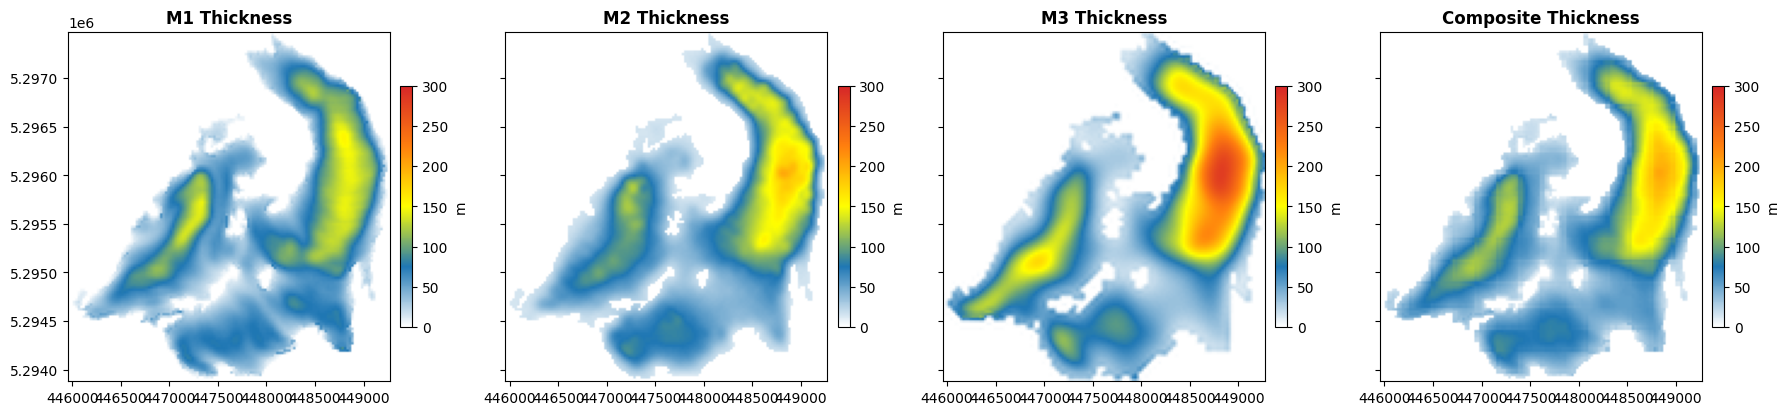

In [17]:
# Thickess Plots
cmap2 = LinearSegmentedColormap.from_list('', ['white', 'tab:blue', 'yellow', 'tab:orange', 'tab:red'])

fig, ax = plt.subplots(1, 4, figsize = [18, 16], sharey = True)

colors = ax[0].imshow(m1_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,
                      axes=ax[0])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[0].set_title('M1 Thickness', fontweight = 'bold')
ax[0].set_aspect("equal")

colors = ax[1].imshow(m2_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,                        
                      axes=ax[1])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[1].set_title('M2 Thickness', fontweight = 'bold')
ax[1].set_aspect("equal")

colors = ax[2].imshow(m3_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,                        
                      axes=ax[2])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[2].set_title('M3 Thickness', fontweight = 'bold')
ax[2].set_aspect("equal")

colors = ax[3].imshow(CompositeSurf_obs[0, :, :],
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      vmax = 300,
                      axes=ax[3])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[3].set_title('Composite Thickness', fontweight = 'bold')
ax[3].set_aspect("equal")

plt.tight_layout()

In [18]:
# Farinotti Model 1 Bed File
bed_file = rasterio.open(blue_bed_m1)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs_m1 = bed_file.read(window=window)

# Farinotti Model 2 Bed File
bed_file = rasterio.open(blue_bed_m2)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs_m2 = bed_file.read(window=window)

# Farinotti Model 3 Bed File
bed_file = rasterio.open(blue_bed_m3)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=bed_file.transform).round_lengths().round_offsets()
transform = bed_file.window_transform(window)
b_obs_m3 = bed_file.read(window=window)

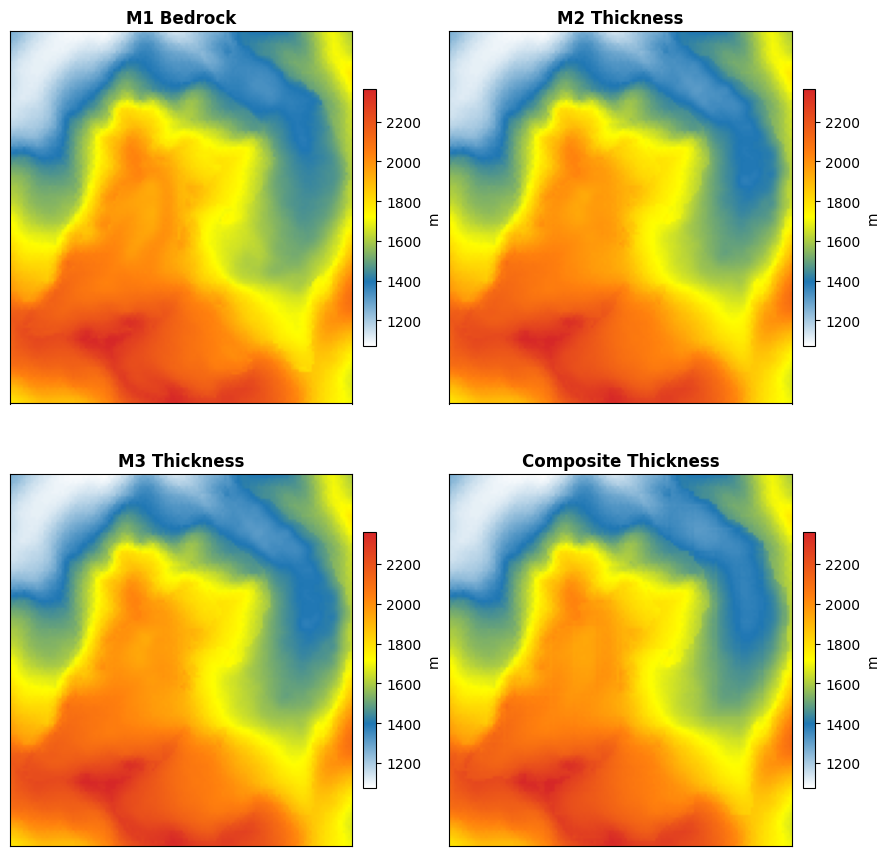

In [19]:
# Bedrock Plots
fig, ax = plt.subplots(2, 2, figsize = [9, 9], sharey = True, sharex = True)

colors = ax[0,0].imshow(b_obs_m1[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      axes=ax[0,0])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[0,0].set_title('M1 Bedrock', fontweight = 'bold')
ax[0,0].set_aspect("equal")

colors = ax[0,1].imshow(b_obs_m2[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      axes=ax[0,1])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[0,1].set_title('M2 Thickness', fontweight = 'bold')
ax[0,1].set_aspect("equal")

colors = ax[1,0].imshow(b_obs_m2[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      axes=ax[1,0])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[1,0].set_title('M3 Thickness', fontweight = 'bold')
ax[1,0].set_aspect("equal")

colors = ax[1,1].imshow(b_obs_comp,
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      cmap = cmap2,
                      axes=ax[1,1])
fig.colorbar(colors, label="m", location = 'right', fraction=0.035, pad=0.03)
ax[1,1].set_title('Composite Thickness', fontweight = 'bold')
ax[1,1].set_aspect("equal")

ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[1,0].set_xticks([])
ax[1,1].set_xticks([])

ax[1,0].set_yticks([])

plt.tight_layout()

## ITS_LIVE Velocity and Mesh

In [20]:
# ITSLIVE Velocity Plot
velo_file = rasterio.open(il_velo)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file.transform).round_lengths().round_offsets()
transform = velo_file.window_transform(window)
velo_obs = velo_file.read(window=window)

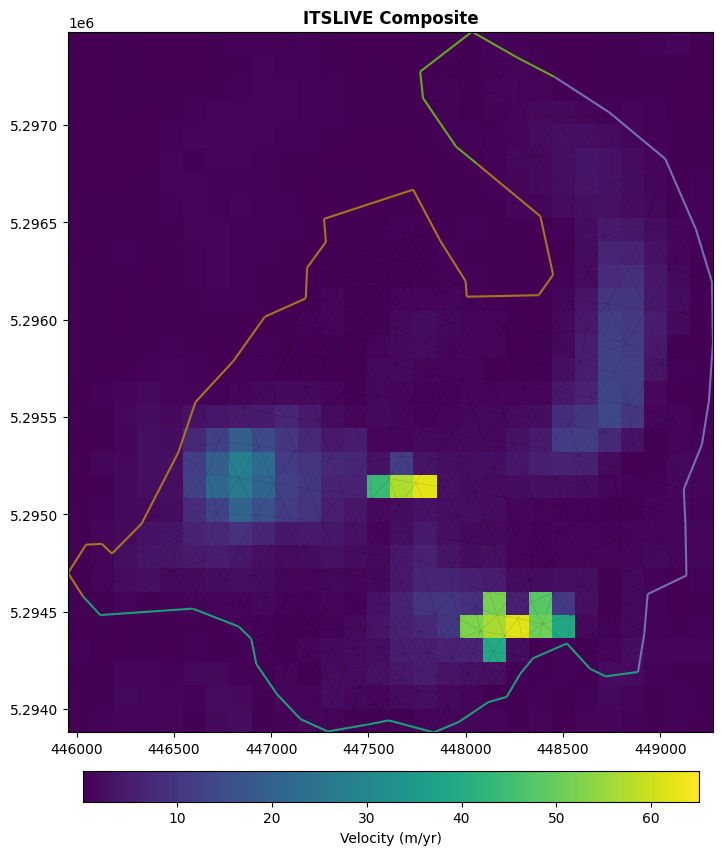

In [21]:
fig, ax = plt.subplots(1, 1, figsize = [12, 10])
#firedrake.triplot(mesh, axes=ax)
colors = ax.imshow(velo_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      vmax = 65,
                      axes=ax);
fig.colorbar(colors, label="Velocity (m/yr)", location = 'bottom', fraction=0.04, pad=0.05, ax = ax);
ax.set_title('ITSLIVE Composite', fontweight = 'bold');
ax.set_aspect("equal");
firedrake.triplot(mesh, axes=ax, **kw);
#ax.set_xticks([])
#ax.set_yticks([])

## Now that everything is loaded in and aligned we need to do some smoothing and fixing of coords before interpolating to our mesh

In [22]:
def smoove(q_obs, λ):
    q = q_obs.copy(deepcopy=True)
    J = 0.5 * ((q - q_obs)**2 + Constant(λ)**2 * inner(grad(q), grad(q))) * dx
    F = firedrake.derivative(J, q)
    firedrake.solve(F == 0, q)
    return q

def fix_obs(field):
    coord_dims = field.shape

    xs = np.linspace(extent['left'], extent['right'], coord_dims[1])
    ys = np.linspace(extent['bottom'], extent['top'], coord_dims[0])

    field_new = xr.DataArray(field, 
                  dims=("y", "x"), 
                  coords={"x": xs , "y": ys[::-1]})

    return field_new


λ = 8e3 #2e3 -> step by 2e3

In [23]:
# Farinotti Model 1
m1 = fix_obs(m1_obs[0, :, :])
h_o1 = icepack.interpolate(m1, Q)
h_m1 = firedrake.project(smoove(h_o1, λ), Q)

# Farinotti Model 2
m2 = fix_obs(m2_obs[0, :, :])
h_o2 = icepack.interpolate(m2, Q)
h_m2 = firedrake.project(smoove(h_o2, λ), Q)

# Farinotti Model 3
m3 = fix_obs(m3_obs[0, :, :])
h_o3 = icepack.interpolate(m3, Q)
h_m3 = firedrake.project(smoove(h_o3, λ), Q)

# Farinotti Model Composite
cs = fix_obs(CompositeSurf_obs[0, :, :])
h_ocs = icepack.interpolate(cs, Q)
h_cs = firedrake.project(smoove(h_ocs, λ), Q)

# Surface DEM
s_d = fix_obs(s_obs)
s_o = icepack.interpolate(s_d, Q)
s_far = firedrake.project(smoove(s_o, λ), Q)

# Bedrock DEM: Composite
b_d = fix_obs(b_obs_comp)
b_o = icepack.interpolate(b_d, Q)
b_c_far = firedrake.project(smoove(b_o, λ), Q)

# ITS_LIVE Velocity
v_d = fix_obs(velo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
v0 = firedrake.project(smoove(v_o, λ), Q)

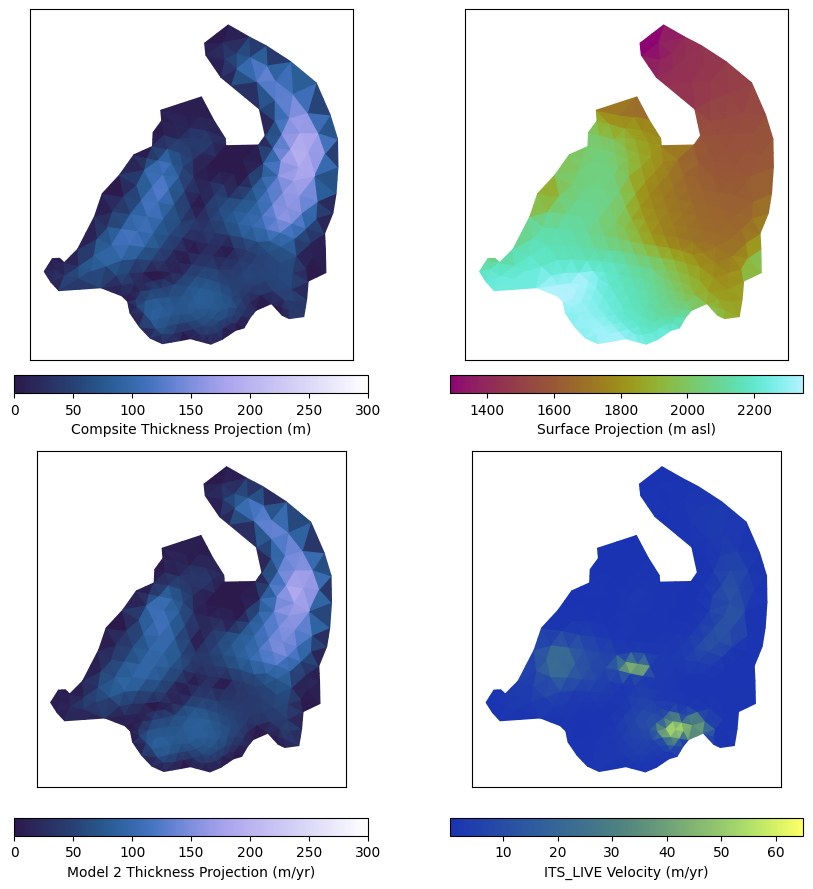

In [24]:
fig, ax = plt.subplots(2, 2, figsize = [9, 9], sharex = True, sharey = True)

colors = firedrake.tripcolor(h_cs, 
                             vmax = 300,
                             cmap = cmc.devon,
                             axes=ax[0,0])
fig.colorbar(colors, label="Compsite Thickness Projection (m)", location = 'bottom', fraction=0.046, pad=0.04)
ax[0,0].set_aspect("equal")
ax[0,0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0,0].tick_params(which='both')
ax[0,0].tick_params(which='major')
ax[0,0].tick_params(which='minor')
ax[0,0].yaxis.set_minor_locator(AutoMinorLocator())

ax[0,0].grid()
ax[0,0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

colors = firedrake.tripcolor(s_far, 
                              axes=ax[0,1], 
                              cmap = cmc.hawaii
                             )
fig.colorbar(colors, label="Surface Projection (m asl)", location = 'bottom',fraction=0.046, pad=0.04)

ax[0,1].set_aspect("equal")

colors = firedrake.tripcolor(h_m2, 
                             vmax = 300,
                             cmap = cmc.devon,
                             axes=ax[1,0])
ax[0,1].grid()
ax[0,1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.colorbar(colors, label="Model 2 Thickness Projection (m/yr)", location = 'bottom',fraction=0.046, pad=0.08)
ax[1,0].set_aspect("equal")


colors = firedrake.tripcolor(v0, 
                             vmax = 65, 
                             cmap = cmc.imola,
                             axes=ax[1,1])
fig.colorbar(colors, label="ITS_LIVE Velocity (m/yr)", location = 'bottom',fraction=0.046, pad=0.08)
ax[1,1].set_aspect("equal")

ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[1,0].set_xticks([])
ax[1,1].set_xticks([])

ax[1,0].set_yticks([])

#fig.suptitle(f'Smoothed and Interpolated Initial Fields ({λ} m)', y = 0.93, fontweight = 'bold')
fig.tight_layout()
fig.savefig('inputs.png', bbox_inches='tight', dpi = 300)

#basemap, north arrow, scale bar

#### Model 2 at initial glance appears to be the most probable. First run throughs of Initial Solves will use the model 2 thickness

# Initial Solves (SIA vs. Hybrid)

In [25]:
from icepack2.constants import gravity as g, ice_density as ρ_I, glen_flow_law, water_density as ρ_W

In [26]:
# Average temperature for weather stations around Emmons, in K
T_ave = 280 # to be changed, need to find blue glacier average temperature
A = icepack.rate_factor(Constant(T_ave))

In [27]:
A / icepack.rate_factor(273.15) # enhancement factor

Division(Constant([709.96418191], name='constant_146', count=146), FloatValue(158.8409918121329))

In [28]:
h0 = h_m2
s0 = s_far

In [29]:
# Method for DG0 surface
ρ = Constant(ρ_I)
g = Constant(g)
ρ_W = Constant(ρ_W)

τ_d = firedrake.Function(V)
σ = firedrake.TestFunction(V)
ν = firedrake.FacetNormal(mesh)

F_cells = (inner(τ_d, σ) + ρ*g*h0 * inner(grad(s0), σ)) * dx
F_facets = -inner(avg(ρ*g*h0) * jump(s0, ν), avg(σ)) * dS
F = F_cells + F_facets

firedrake.solve(F == 0, τ_d)

Text(0.5, 1.0, 'SIA τ_d [MPa]')

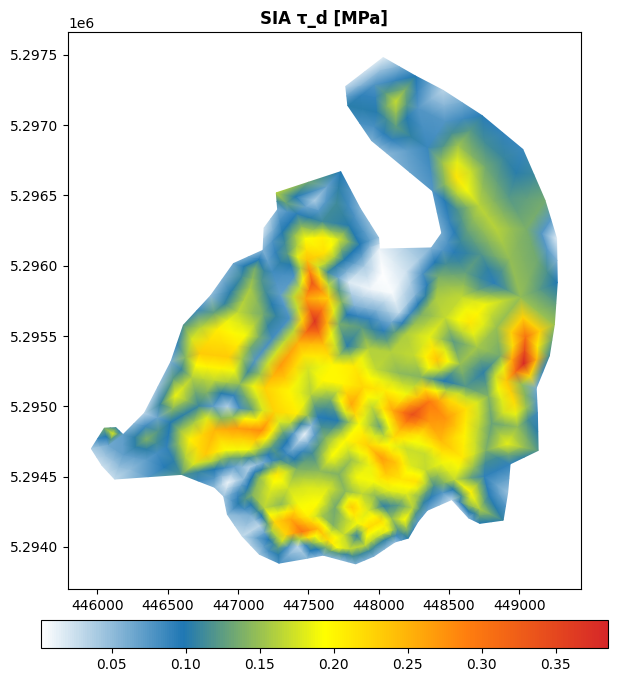

In [30]:
fig, axes = plt.subplots(figsize = (8, 8), sharex = True, sharey = True)

axes.set_aspect("equal")
colors = firedrake.tripcolor(τ_d, 
                             cmap = cmap2, 
                             #vmax = 400, 
                             axes=axes)
fig.colorbar(colors, fraction=0.046, pad=0.05, orientation = 'horizontal')
axes.set_title('SIA τ_d [MPa]', fontweight = 'bold')

In [31]:
from icepack2.constants import gravity as g, ice_density as ρ, glen_flow_law

n = Constant(glen_flow_law)

u_sia = firedrake.Function(V)
v = firedrake.TestFunction(V)

u_shear = (-2/(n+2)) * h0 * A * (inner(τ_d, τ_d) ** 0.5) ** (n-1) * τ_d
F = inner(u_sia - u_shear, v) * dx

solver_params = {"snes_type": "ksponly", "ksp_type": "gmres"}
fc_params = {"quadrature_degree": 6}
params = {"solver_parameters": solver_params, "form_compiler_parameters": fc_params}
firedrake.solve(F == 0, u_sia, **params)

In [32]:
dg0 = firedrake.FiniteElement("DG", "triangle", 0)

u = firedrake.Function(V)

Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)
Z = V * Σ * T
z = firedrake.Function(Z)

z.sub(0).assign(u);

In [33]:
h = h0.copy(deepcopy = True)
s = s0.copy(deepcopy = True)
b = b_c_far.copy(deepcopy = True)

## Sliding Law

In [34]:
τ_c = Constant(0.1) # Critical Stress (set to 0.1 mPa)
ε_c = Constant(A * τ_c ** n) # multiply by very small Λ for SIA-like

K = h * A / (n + 2)

t = Constant(0.0)
U_0 = Constant(10.0)
ΔU = Constant(0.0)

U_c = U_0 + ΔU * firedrake.sin(2 * pi * t)# + ϕ) # Critical velocity -> 0 completely turns of long. stress (SIA-like) 100
#U_c = Constant(8.0) 
u_c = K * τ_c ** n + U_c

In [35]:
glen_rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

α = firedrake.Constant(1e-4)
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
}

u, M, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
}

v, N, σ = firedrake.TestFunctions(Z)

In [36]:
degree = 1
qdegree = max(8, degree ** glen_flow_law)
inflow_ids = [1]
#side_wall_ids = [1, 3]
bc = firedrake.DirichletBC(Z.sub(0), Constant((5.0, 11.0)), inflow_ids)# -----> Inflow set to some velocity prof
pparams = {
    "bcs": bc,
    "form_compiler_parameters": {"quadrature_degree": qdegree},
}

sparams = {
    "solver_parameters": {
        "snes_monitor": None,
        #"snes_linesearch_monitor": None,
        "snes_type": "newtonls",
        "snes_max_it": 200,
        "snes_divergence_tolerance": 1e250,
        "snes_linesearch_type": "l2",
        "snes_linesearch_max_it": 5,
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

In [37]:
from icepack2 import model
from icepack2.model.variational import momentum_balance, flow_law, friction_law

H = Constant(100.0)

F = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

momentum_problem = firedrake.NonlinearVariationalProblem(F, z, **pparams)
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, **sparams)

In [38]:
num_continuation_steps = 10
for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
    n.assign(exponent)
    momentum_solver.solve()

  0 SNES Function norm 8.058774093839e+05
  1 SNES Function norm 1.585374628577e-07
  0 SNES Function norm 2.781426802373e+08
  1 SNES Function norm 3.783251276831e+06
  2 SNES Function norm 3.718942574835e+04
  3 SNES Function norm 1.330801966550e+03
  4 SNES Function norm 4.179058802799e+00
  5 SNES Function norm 5.081077625056e-05
  0 SNES Function norm 1.694103635322e+08
  1 SNES Function norm 2.946054037489e+06
  2 SNES Function norm 6.345269538775e+04
  3 SNES Function norm 7.447637794217e+02
  4 SNES Function norm 4.797986038766e-01
  0 SNES Function norm 1.029963420777e+08
  1 SNES Function norm 1.860346965427e+06
  2 SNES Function norm 4.290334078787e+04
  3 SNES Function norm 2.542387152589e+03
  4 SNES Function norm 5.669616739545e+01
  5 SNES Function norm 3.298004759211e-02
  0 SNES Function norm 6.284673643794e+07
  1 SNES Function norm 1.119106820211e+06
  2 SNES Function norm 2.166503039639e+04
  3 SNES Function norm 3.725323320815e+02
  4 SNES Function norm 6.598711727

In [39]:
u_init, M_init, τ_init = z.subfunctions
u_init.dat.data_ro.max()

np.float64(118.37222264989497)

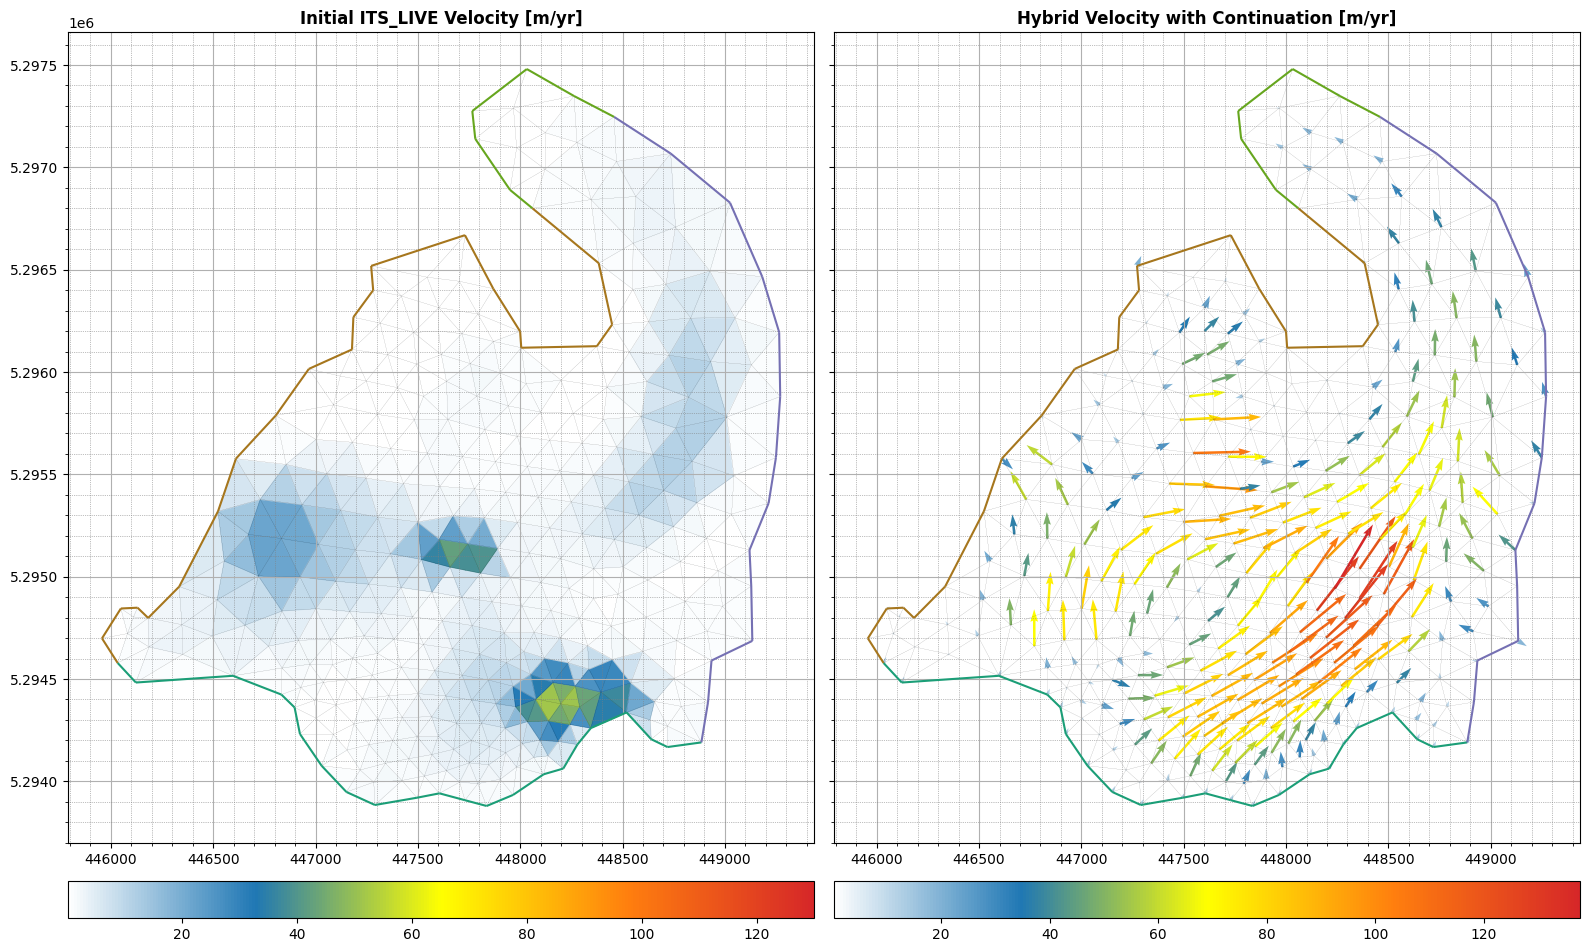

In [40]:
u_init, M_init, τ_init = z.subfunctions

fig, axes = plt.subplots(1, 2, figsize = (16, 10), sharex = True, sharey = True)

axes[0].set_aspect("equal")
colors = firedrake.tripcolor(v0, 
                             cmap = cmap2, 
                             vmax = 130, 
                             axes=axes[0])
fig.colorbar(colors, fraction=0.046, pad=0.04, orientation = 'horizontal')
firedrake.triplot(mesh, axes=axes[0], **kw)
axes[0].set_title('Initial ITS_LIVE Velocity [m/yr]', fontweight = 'bold')
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both')
axes[0].tick_params(which='major')
axes[0].tick_params(which='minor')
axes[0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0].grid()
axes[0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

axes[1].set_aspect("equal")
colors = firedrake.quiver(u_init, 
                             cmap = cmap2, 
                             #vmax = 130,  
                             axes=axes[1])
fig.colorbar(colors, fraction=0.046, pad=0.04, orientation = 'horizontal')
firedrake.triplot(mesh, axes=axes[1], **kw)
axes[1].set_title('Hybrid Velocity with Continuation [m/yr]', fontweight = 'bold')
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both')
axes[1].tick_params(which='major')
axes[1].tick_params(which='minor')
axes[1].yaxis.set_minor_locator(AutoMinorLocator())

axes[1].grid()
axes[1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()

## SMB Fields

In [ ]:
# Type 1
z_measured = Constant(900.0)

a_measured = Constant(-0.917 * 8.7)

a_top = Constant(8.7)

z_top = Constant(4e3)

δa_δz = (a_top - a_measured) / (z_top - z_measured)
δa_δz_std = 0.25
δa_δz_noise = np.random.normal(0, δa_δz_std, size=dummy_steps)

a_max = Constant(3.7)

def smb1(z, δa_δz_noise):
    return min_value(a_max, a_measured + (δa_δz + δa_δz_noise) * (z - z_measured))

In [ ]:
# Type 2
s_min = s.dat.data_ro.min()
s_max = s.dat.data_ro.max()
s_diff = int(np.round(s_max - s_min))
s_vals = np.linspace(s_min, s_max, s_diff)

a_vals = np.zeros(s_diff)
a_valStart = np.zeros(s_diff)

In [ ]:
ela = 2550
abl_start = -25    
abl_m = (-1 * abl_start) / ela

acu_start = -20
accum_m = (-1 * acu_start) / ela

debris_melt = -2.5
debris_elev = 2100

a_max = 5.0

## This is for visualization only, but uses the same information as above
for i in range(len(s_vals)):
    if s_vals[i] <= debris_elev:
        a_vals[i] = debris_melt # min_value(a_max, abl_start + abl_m * s_vals[i])
    elif s_vals[i] < ela:
        a_vals[i] = min_value(a_max, abl_start + abl_m * s_vals[i])
    elif s_vals[i] == ela:
        a_vals[i] = 0
    elif s_vals[i] > ela:
        a_vals[i] = min_value(a_max, acu_start + accum_m * s_vals[i-1])

In [ ]:
ela = 2300
abl_start = -24    
abl_m = (-1 * abl_start) / ela

acu_start = -12
accum_m = (-1 * acu_start) / ela


a_max = 7

## This is for visualization only, but uses the same information as above
for i in range(len(s_vals)):
    if s_vals[i] < ela:
        a_valStart[i] = min_value(a_max, abl_start + abl_m * s_vals[i])
    elif s_vals[i] == ela:
        a_valStart[i] = 0
    elif s_vals[i] > ela:
        a_valStart[i] = min_value(a_max, acu_start + accum_m * s_vals[i-1])

In [ ]:
expr3 = conditional( # Below ela
    ela >= s,
    abl_start + abl_m * s,
    0,
)

expr2 = conditional( # Above ela
    ela < s,                                        #condition
    min_value(a_max, acu_start + accum_m * s),      # true val
    expr3,                                          # false val
)

expr = conditional( # Below 0 
    debris_elev > s,
    debris_melt, 
    expr2
)

def smb2(s):
    return expr

# This is where we can switch between SMB types. Type 1 is the more classic icepack style of SMB while 
# type 2 is a multislope approach that accounts for debris cover. 
a = firedrake.Function(Q).interpolate(smb2(s))
a.dat.data_ro.sum()

In [ ]:
fig, axes = plt.subplots(figsize = (8, 8), sharex = True, sharey = True)

axes.set_aspect("equal")
firedrake.triplot(mesh, axes=axes)
colors = firedrake.tripcolor(a, alpha = 0.9, axes=axes)

fig.colorbar(colors, fraction=0.046, pad=0.05, orientation = 'horizontal')
axes.set_title('SMB [m w.e.] ', fontweight = 'bold')

axes.xaxis.set_minor_locator(AutoMinorLocator())
axes.tick_params(which='both')
axes.tick_params(which='major')
axes.tick_params(which='minor')
axes.yaxis.set_minor_locator(AutoMinorLocator())

axes.grid()
axes.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')